<a href="https://colab.research.google.com/github/AndreiAf02/Data-Balancing-in-ML-DNN/blob/main/CIFAR10_Fine_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##CIFAR-10 Dataset - Predicting Cats vs Dogs using Fine-tuning TL on Deer vs Horses

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from time import perf_counter



from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
# !pip install pytorch-tabnet

# from pytorch_tabnet.tab_model import TabNetClassifier
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


from keras.datasets import mnist, fashion_mnist, cifar10


## Collecting the CIFAR-10 Data:

In [2]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

In [3]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

[4]


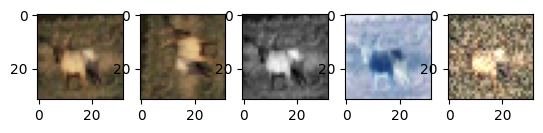

In [4]:
i = 3

print(train_labels[i])

figure_for_plotting = train_images[i] #.transpose((1, 0, 2))
plt.subplot(1, 5, 1)
plt.imshow(figure_for_plotting)

plt.subplot(1, 5, 2)
plt.imshow(figure_for_plotting.transpose((1, 0, 2)))

# np.clip(noisy_figure, 0, 255)
gs_figure_for_plotting = np.mean(train_images[i],axis=2)
plt.subplot(1, 5, 3)
plt.imshow(gs_figure_for_plotting, cmap='gray')


plt.subplot(1, 5, 4)
plt.imshow(-figure_for_plotting)


noisy_figure = figure_for_plotting + np.random.randint(0,100,size=(figure_for_plotting.shape[0], figure_for_plotting.shape[1], 1))
noisy_figure = np.clip(noisy_figure, 0, 255)

plt.subplot(1, 5, 5)
plt.imshow(noisy_figure)

## Creating the Imbalanced Source training set using Data Augmentation (Deer vs Horses):

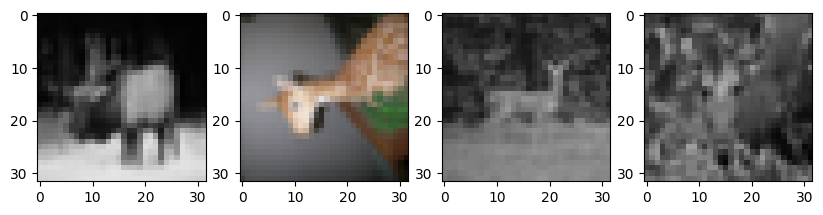

In [5]:
maj_label=4
min_label=7

max_noise = 100

# train_binary_maj = train_images[np.where(np.isin(train_labels,[maj_label,min_label]))]
maj_index = np.where(train_labels == maj_label)
train_binary_label1 = train_images[maj_index[0]]

# train_binary_maj = train_binary_label1

orig_maj_len = len(train_binary_label1)

# train_binary_maj.shape

# Incorporating the transposed image:
maj_transpose = train_binary_label1.transpose((0, 2, 1, 3))
# train_binary_maj = np.append(train_binary_maj, maj_transpose, axis=0)
train_binary_maj = maj_transpose

# ## Incorporating the negative image:
# maj_negative = 255 - train_binary_label1
# train_binary_maj = np.append(train_binary_maj, maj_negative, axis=0)

## Incoporating the grayscale image:
gs_fig = train_binary_label1.mean(axis=3).astype(int)
gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
gs_fig = gs_fig.transpose((1, 2, 3, 0))
gs_fig.shape
train_binary_maj = np.append(train_binary_maj, gs_fig, axis=0)

## Incorporating the noisy image:
noisy_figure = train_binary_label1 + np.random.randint(0,max_noise,size=(train_binary_label1.shape[0], train_binary_label1.shape[1], train_binary_label1.shape[2], 1))
noisy_figure = np.clip(noisy_figure, 0, 255)
train_binary_maj = np.append(train_binary_maj, noisy_figure, axis=0)

np.random.seed(333)
np.random.shuffle(train_binary_maj)

# print(train_binary_maj)


## Plotting the example figures:
plt.figure(figsize=(10, 30))
plt.subplot(1, 4, 1)
plt.imshow(train_binary_maj[1])

plt.subplot(1, 4, 2)
plt.imshow(train_binary_maj[2])

# plt.subplot(1, 5, 3)
# plt.imshow(train_binary_maj[3*orig_maj_len-1])

plt.subplot(1, 4, 3)
plt.imshow(train_binary_maj[3])

plt.subplot(1, 4, 4)
plt.imshow(train_binary_maj[5])




Text(0.5, 1.0, 'Original Figure')

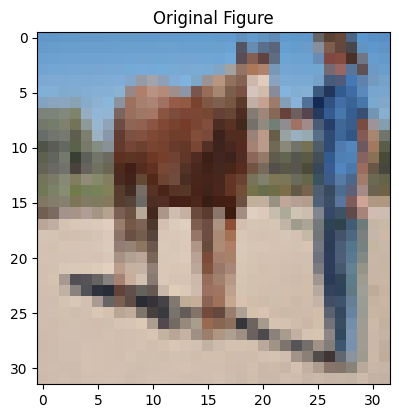

In [6]:
min_index = np.where(train_labels == min_label)
train_binary_label2 = train_images[min_index[0]]


train_binary_min = train_binary_label2

# noisy_figure = train_binary_label2 + np.random.randint(0,max_noise,size=(train_binary_label2.shape[0], train_binary_label2.shape[1], train_binary_label2.shape[2], 1))
# noisy_figure = np.clip(noisy_figure, 0, 255)
# train_binary_min = noisy_figure


plt.figure(figsize=(10, 12))
plt.subplot(1, 2, 1)
plt.imshow(train_binary_label2[-1])
plt.title('Original Figure')

# plt.subplot(1, 2, 2)
# plt.imshow(train_binary_min[-1])
# plt.title('Noisy Figure')

In [7]:
print(train_binary_maj.shape)
print(train_binary_min.shape)


train_maj_label = [maj_label]*len(train_binary_maj)
train_min_label = [min_label]*len(train_binary_min)

train_maj_label_binary = [0]*len(train_binary_maj)
train_min_label_binary = [1]*len(train_binary_min)

train_binary_total = np.append(train_binary_maj, train_binary_min, axis=0)
train_label_total = train_maj_label + train_min_label
train_label_total_binary = train_maj_label_binary + train_min_label_binary

pd.Series(train_label_total_binary).value_counts()


(15000, 32, 32, 3)
(5000, 32, 32, 3)


,count
0,15000
1,5000


In [8]:
train_binary_scaled = train_binary_total.astype('float32')/255.
train_binary_flattened = train_binary_scaled.reshape(train_binary_scaled.shape[0], -1)
train_binary_flattened = pd.DataFrame(train_binary_flattened)
train_binary_flattened['Y'] = train_label_total_binary

train_binary_flattened.tail()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
19995,0.698039,0.741176,0.745098,0.501961,0.552941,0.560784,0.533333,0.592157,0.576471,0.498039,...,0.403922,0.509804,0.247059,0.403922,0.517647,0.235294,0.368627,0.494118,0.215686,1
19996,0.227451,0.274510,0.235294,0.250980,0.301961,0.262745,0.203922,0.250980,0.211765,0.243137,...,0.627451,0.615686,0.074510,0.631373,0.623529,0.070588,0.545098,0.517647,0.078431,1
19997,0.870588,0.862745,0.870588,0.854902,0.847059,0.854902,0.886275,0.878431,0.886275,0.909804,...,0.164706,0.145098,0.129412,0.439216,0.454902,0.470588,0.560784,0.592157,0.650980,1
19998,0.643137,0.639216,0.588235,0.368627,0.321569,0.219608,0.466667,0.400000,0.301961,0.494118,...,0.898039,0.941176,0.917647,0.874510,0.898039,0.882353,0.996078,0.996078,0.996078,1
19999,0.380392,0.592157,0.788235,0.384314,0.596078,0.788235,0.388235,0.600000,0.788235,0.388235,...,0.803922,0.729412,0.666667,0.768627,0.701961,0.639216,0.764706,0.698039,0.639216,1


## Creating the Imbalanced Source testing set using Data Augmentation:

3000


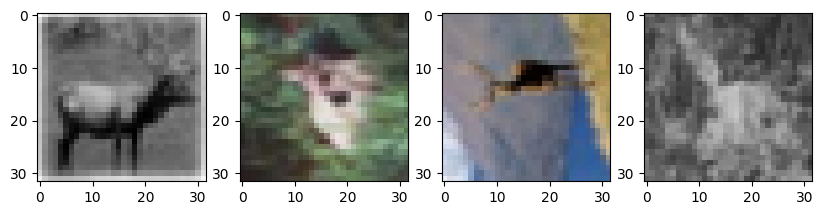

In [9]:
maj_index = np.where(test_labels == maj_label)
test_binary_label1 = test_images[maj_index[0]]

# test_binary_maj = test_binary_label1

orig_maj_len = len(test_binary_label1)

# test_binary_maj.shape

# Incorporating the transposed image:
maj_transpose = test_binary_label1.transpose((0, 2, 1, 3))
# test_binary_maj = np.append(test_binary_maj, maj_transpose, axis=0)
test_binary_maj = maj_transpose

# ## Incorporating the negative image:
# maj_negative = 255 - test_binary_label1
# test_binary_maj = np.append(test_binary_maj, maj_negative, axis=0)

## Incoporating the grayscale image:
gs_fig = test_binary_label1.mean(axis=3).astype(int)
gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
gs_fig = gs_fig.transpose((1, 2, 3, 0))
gs_fig.shape
test_binary_maj = np.append(test_binary_maj, gs_fig, axis=0)

## Incorporating the noisy image:
noisy_figure = test_binary_label1 + np.random.randint(0,max_noise,size=(test_binary_label1.shape[0], test_binary_label1.shape[1], test_binary_label1.shape[2], 1))
noisy_figure = np.clip(noisy_figure, 0, 255)
test_binary_maj = np.append(test_binary_maj, noisy_figure, axis=0)

np.random.seed(333)
np.random.shuffle(test_binary_maj)

print(len(test_binary_maj))


## Plotting the example figures:
plt.figure(figsize=(10, 30))
plt.subplot(1, 4, 1)
plt.imshow(test_binary_maj[1])

plt.subplot(1, 4, 2)
plt.imshow(test_binary_maj[2])

# plt.subplot(1, 5, 3)
# plt.imshow(test_binary_maj[3*orig_maj_len-1])
# plt.title('Negative')

plt.subplot(1, 4, 3)
plt.imshow(test_binary_maj[3])

plt.subplot(1, 4, 4)
plt.imshow(test_binary_maj[4])




Text(0.5, 1.0, 'Original Figure')

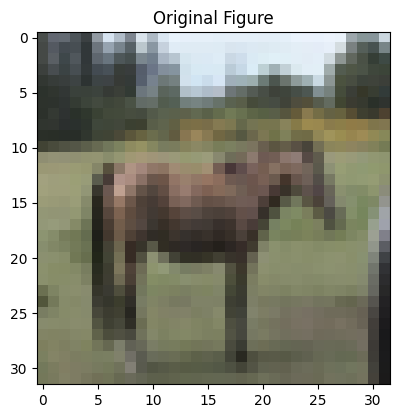

In [10]:
min_index = np.where(test_labels == min_label)
test_binary_label2 = test_images[min_index[0]]

test_binary_min = test_binary_label2

# noisy_figure = test_binary_label2 + np.random.randint(0,max_noise,size=(test_binary_label2.shape[0], test_binary_label2.shape[1], test_binary_label2.shape[2], 1))
# noisy_figure = np.clip(noisy_figure, 0, 255)
# test_binary_min = noisy_figure


plt.figure(figsize=(10, 12))
plt.subplot(1, 2, 1)
plt.imshow(test_binary_label2[-1])
plt.title('Original Figure')

# plt.subplot(1, 2, 2)
# plt.imshow(test_binary_min[-1])
# plt.title('Noisy Figure')

In [11]:
print(test_binary_maj.shape)
print(test_binary_min.shape)


test_maj_label = [maj_label]*len(test_binary_maj)
test_min_label = [min_label]*len(test_binary_min)

test_maj_label_binary = [0]*len(test_binary_maj)
test_min_label_binary = [1]*len(test_binary_min)

test_binary_total = np.append(test_binary_maj, test_binary_min, axis=0)
test_label_total = test_maj_label + test_min_label
test_label_total_binary = test_maj_label_binary + test_min_label_binary

pd.Series(test_label_total_binary).value_counts()


(3000, 32, 32, 3)
(1000, 32, 32, 3)


,count
0,3000
1,1000


In [12]:
test_binary_scaled = test_binary_total.astype('float32')/255.
test_binary_flattened = test_binary_scaled.reshape(test_binary_scaled.shape[0], -1)
test_binary_flattened = pd.DataFrame(test_binary_flattened)
test_binary_flattened['Y'] = test_label_total_binary

test_binary_flattened.tail()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
3995,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.776471,0.721569,0.596078,0.772549,0.709804,0.576471,0.780392,0.709804,0.572549,1
3996,0.062745,0.094118,0.050980,0.019608,0.058824,0.023529,0.031373,0.086275,0.043137,0.043137,...,0.505882,0.415686,0.329412,0.498039,0.407843,0.321569,0.482353,0.400000,0.309804,1
3997,0.125490,0.129412,0.086275,0.172549,0.219608,0.117647,0.243137,0.274510,0.172549,0.380392,...,0.701961,0.580392,0.494118,0.705882,0.580392,0.494118,0.698039,0.556863,0.478431,1
3998,0.329412,0.470588,0.384314,0.384314,0.490196,0.403922,0.388235,0.490196,0.411765,0.392157,...,0.552941,0.580392,0.552941,0.498039,0.517647,0.498039,0.333333,0.352941,0.317647,1
3999,0.286275,0.305882,0.294118,0.384314,0.403922,0.443137,0.388235,0.415686,0.447059,0.301961,...,0.454902,0.450980,0.368627,0.266667,0.254902,0.227451,0.105882,0.101961,0.101961,1


In [13]:
train_binary_flattened['test'] = 0
test_binary_flattened['test'] = 1
data_source = pd.concat([train_binary_flattened, test_binary_flattened])

data_source.tail()

,0,1,2,3,4,5,6,7,8,9,...,3064,3065,3066,3067,3068,3069,3070,3071,Y,test
3995,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.721569,0.596078,0.772549,0.709804,0.576471,0.780392,0.709804,0.572549,1,1
3996,0.062745,0.094118,0.050980,0.019608,0.058824,0.023529,0.031373,0.086275,0.043137,0.043137,...,0.415686,0.329412,0.498039,0.407843,0.321569,0.482353,0.400000,0.309804,1,1
3997,0.125490,0.129412,0.086275,0.172549,0.219608,0.117647,0.243137,0.274510,0.172549,0.380392,...,0.580392,0.494118,0.705882,0.580392,0.494118,0.698039,0.556863,0.478431,1,1
3998,0.329412,0.470588,0.384314,0.384314,0.490196,0.403922,0.388235,0.490196,0.411765,0.392157,...,0.580392,0.552941,0.498039,0.517647,0.498039,0.333333,0.352941,0.317647,1,1
3999,0.286275,0.305882,0.294118,0.384314,0.403922,0.443137,0.388235,0.415686,0.447059,0.301961,...,0.450980,0.368627,0.266667,0.254902,0.227451,0.105882,0.101961,0.101961,1,1


In [14]:
data_source['Y'].value_counts()

,count
Y,
0,18000
1,6000


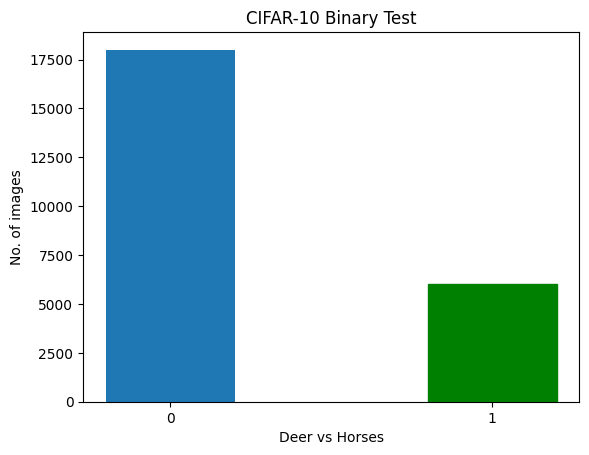

In [15]:
barlist = plt.bar([str(0),str(1)], data_source['Y'].value_counts(), width = 0.4)
barlist[1].set_color('g')

plt.xlabel("Deer vs Horses")
plt.ylabel("No. of images")
plt.title("CIFAR-10 Binary Test")
plt.show()

## Creating the Imbalanced Target training set using Data Augmentation (Cats vs Dogs):

In [16]:
train_binary_label1[:int(len(train_binary_label1)/5)].shape

(1000, 32, 32, 3)

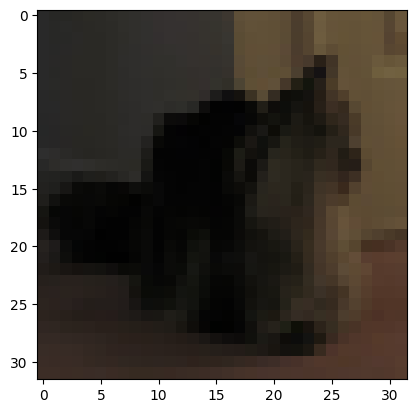

In [17]:
maj_label=3
min_label=5

max_noise = 100

# train_binary_maj = train_images[np.where(np.isin(train_labels,[maj_label,min_label]))]
maj_index = np.where(train_labels == maj_label)
train_binary_label1 = train_images[maj_index[0]]

train_binary_maj = train_binary_label1
plt.imshow(train_binary_maj[-2])

# # train_binary_maj = train_binary_label1

# orig_maj_len = int(len(train_binary_label1)/4)

# # train_binary_maj.shape

# # Incorporating the transposed image:
# maj_transpose = train_binary_label1[:orig_maj_len].transpose((0, 2, 1, 3))
# # train_binary_maj = np.append(train_binary_maj, maj_transpose, axis=0)
# train_binary_maj = maj_transpose

# # ## Incorporating the negative image:
# # maj_negative = 255 - train_binary_label1
# # train_binary_maj = np.append(train_binary_maj, maj_negative, axis=0)

# ## Incoporating the grayscale image:
# gs_fig = train_binary_label1[orig_maj_len:2*orig_maj_len].mean(axis=3).astype(int)
# gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
# gs_fig = gs_fig.transpose((1, 2, 3, 0))
# gs_fig.shape
# train_binary_maj = np.append(train_binary_maj, gs_fig, axis=0)

# ## Incorporating the noisy image:
# noisy_figure = (train_binary_label1[2*orig_maj_len:3*orig_maj_len]
#                 + np.random.randint(0,max_noise,size=(train_binary_label1[2*orig_maj_len:3*orig_maj_len].shape[0],
#                                             train_binary_label1[2*orig_maj_len:3*orig_maj_len].shape[1],
#                                             train_binary_label1[2*orig_maj_len:3*orig_maj_len].shape[2], 1)))
# noisy_figure = np.clip(noisy_figure, 0, 255)
# train_binary_maj = np.append(train_binary_maj, noisy_figure, axis=0)


# print(len(train_binary_maj))


# ## Plotting the example figures:
# # plt.figure(figsize=(10, 30))
# # plt.subplot(1, 4, 1)
# # plt.imshow(train_binary_label1[orig_maj_len-1])
# # plt.title('Original Figure')

# plt.subplot(2, 3, 1)
# plt.imshow(train_binary_label1[orig_maj_len-1])
# plt.title('Original')

# plt.subplot(2, 3, 2)
# plt.imshow(train_binary_label1[2*orig_maj_len-1])
# plt.title('Original')

# plt.subplot(2, 3, 3)
# plt.imshow(train_binary_label1[3*orig_maj_len-1])
# plt.title('Original')

# ## Plotting the augmented figures:
# plt.subplot(2, 3, 4)
# plt.imshow(train_binary_maj[orig_maj_len-1])
# plt.title('Transposed')

# # plt.subplot(1, 3, 2)
# # plt.imshow(train_binary_maj[3*orig_maj_len-1])
# # plt.title('Negative')

# plt.subplot(2, 3, 5)
# plt.imshow(train_binary_maj[2*orig_maj_len-1])
# plt.title('Grayscale')

# plt.subplot(2, 3, 6)
# plt.imshow(train_binary_maj[3*orig_maj_len-1])
# plt.title('Noisy')



# np.random.seed(333)
# np.random.shuffle(train_binary_maj)


Text(0.5, 1.0, 'Minority Training Figure')

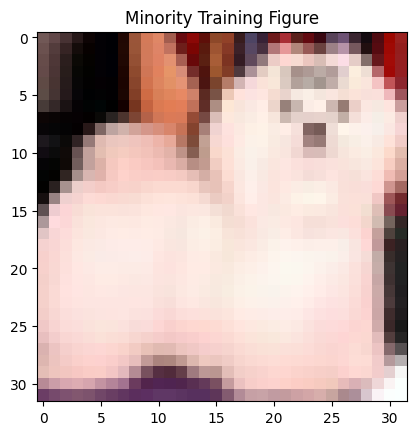

In [18]:
min_index = np.where(train_labels == min_label)
train_binary_label2 = train_images[min_index[0]]

np.random.seed(333)
sampled_min_index = np.random.choice(train_binary_label2.shape[0], size= int(len(train_binary_label2)/2), replace=False)
train_binary_min = train_binary_label2[sampled_min_index]


# train_binary_min = np.random.sample(train_binary_label2, int(len(train_binary_label2)/4))

# noisy_figure = train_binary_label2 + np.random.randint(0,max_noise,size=(train_binary_label2.shape[0], train_binary_label2.shape[1], train_binary_label2.shape[2], 1))
# noisy_figure = np.clip(noisy_figure, 0, 255)
# train_binary_min = noisy_figure


# plt.figure(figsize=(10, 12))
# plt.subplot(1, 2, 1)
# plt.imshow(train_binary_label2[-1])
# plt.title('Original Figure')


plt.imshow(train_binary_min[-1])
plt.title('Minority Training Figure')

In [19]:
print(train_binary_maj.shape)
print(train_binary_min.shape)


train_maj_label = [maj_label]*len(train_binary_maj)
train_min_label = [min_label]*len(train_binary_min)

train_maj_label_binary = [0]*len(train_binary_maj)
train_min_label_binary = [1]*len(train_binary_min)

train_binary_total = np.append(train_binary_maj, train_binary_min, axis=0)
train_label_total = train_maj_label + train_min_label
train_label_total_binary = train_maj_label_binary + train_min_label_binary

pd.Series(train_label_total_binary).value_counts()


(5000, 32, 32, 3)
(2500, 32, 32, 3)


,count
0,5000
1,2500


In [20]:
train_binary_scaled = train_binary_total.astype('float32')/255.
train_binary_flattened = train_binary_scaled.reshape(train_binary_scaled.shape[0], -1)
train_binary_flattened = pd.DataFrame(train_binary_flattened)
train_binary_flattened['Y'] = train_label_total_binary

train_binary_flattened.tail()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
7495,0.039216,0.058824,0.090196,0.047059,0.062745,0.098039,0.047059,0.074510,0.109804,0.062745,...,0.113725,0.145098,0.219608,0.109804,0.149020,0.231373,0.113725,0.149020,0.227451,1
7496,0.729412,0.580392,0.490196,0.713726,0.564706,0.474510,0.721569,0.572549,0.482353,0.721569,...,0.576471,0.458824,0.325490,0.592157,0.470588,0.325490,0.603922,0.478431,0.321569,1
7497,0.780392,0.764706,0.584314,0.698039,0.627451,0.333333,0.694118,0.631373,0.329412,0.682353,...,0.709804,0.639216,0.462745,0.725490,0.639216,0.482353,0.733333,0.647059,0.486275,1
7498,0.250980,0.403922,0.015686,0.352941,0.517647,0.027451,0.231373,0.262745,0.054902,0.176471,...,0.529412,0.576471,0.560784,0.552941,0.584314,0.549020,0.560784,0.592157,0.568627,1
7499,0.443137,0.345098,0.337255,0.380392,0.278431,0.282353,0.278431,0.196078,0.200000,0.149020,...,0.980392,0.952941,0.964706,0.984314,0.996078,0.992157,0.980392,1.000000,0.996078,1


## Creating the Imbalanced Target testing set using Data Augmentation:

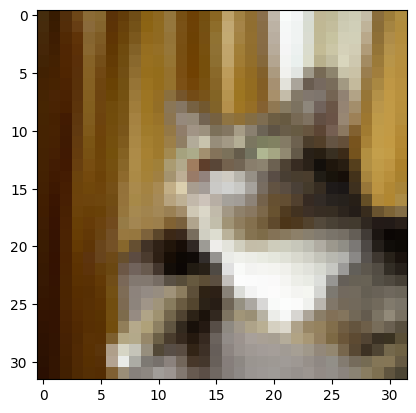

In [21]:
maj_index = np.where(test_labels == maj_label)
test_binary_label1 = test_images[maj_index[0]]

test_binary_maj = test_binary_label1
plt.imshow(test_binary_maj[-2])

# orig_maj_len = int(len(test_binary_label1)/4)

# # Incorporating the transposed image:
# maj_transpose = test_binary_label1[:orig_maj_len].transpose((0, 2, 1, 3))
# test_binary_maj = maj_transpose

# ## Incoporating the grayscale image:
# gs_fig = test_binary_label1[orig_maj_len:2*orig_maj_len].mean(axis=3).astype(int)
# gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
# gs_fig = gs_fig.transpose((1, 2, 3, 0))
# gs_fig.shape
# test_binary_maj = np.append(test_binary_maj, gs_fig, axis=0)

# ## Incorporating the noisy image:
# noisy_figure = (test_binary_label1[2*orig_maj_len:3*orig_maj_len]
#                 + np.random.randint(0,max_noise,size=(test_binary_label1[2*orig_maj_len:3*orig_maj_len].shape[0],
#                                             test_binary_label1[2*orig_maj_len:3*orig_maj_len].shape[1],
#                                             test_binary_label1[2*orig_maj_len:3*orig_maj_len].shape[2], 1)))
# noisy_figure = np.clip(noisy_figure, 0, 255)
# test_binary_maj = np.append(test_binary_maj, noisy_figure, axis=0)


# print(len(test_binary_maj))


# plt.subplot(2, 3, 1)
# plt.imshow(test_binary_label1[orig_maj_len-1])
# plt.title('Original')

# plt.subplot(2, 3, 2)
# plt.imshow(test_binary_label1[2*orig_maj_len-1])
# plt.title('Original')

# plt.subplot(2, 3, 3)
# plt.imshow(test_binary_label1[3*orig_maj_len-1])
# plt.title('Original')

# ## Plotting the augmented figures:
# plt.subplot(2, 3, 4)
# plt.imshow(test_binary_maj[orig_maj_len-1])
# plt.title('Transposed')

# plt.subplot(2, 3, 5)
# plt.imshow(test_binary_maj[2*orig_maj_len-1])
# plt.title('Grayscale')

# plt.subplot(2, 3, 6)
# plt.imshow(test_binary_maj[3*orig_maj_len-1])
# plt.title('Noisy')

# np.random.seed(333)
# np.random.shuffle(test_binary_maj)


Text(0.5, 1.0, 'Minority Testing Figure')

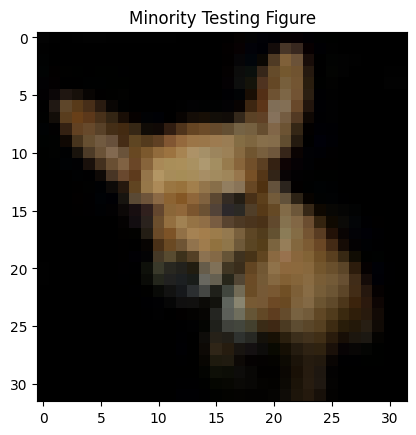

In [22]:
min_index = np.where(test_labels == min_label)
test_binary_label2 = test_images[min_index[0]]

np.random.seed(333)
sampled_min_index = np.random.choice(test_binary_label2.shape[0], size= int(len(test_binary_label2)/2), replace=False)
test_binary_min = test_binary_label2[sampled_min_index]


plt.imshow(test_binary_min[-1])
plt.title('Minority Testing Figure')

In [23]:
print(test_binary_maj.shape)
print(test_binary_min.shape)


test_maj_label = [maj_label]*len(test_binary_maj)
test_min_label = [min_label]*len(test_binary_min)

test_maj_label_binary = [0]*len(test_binary_maj)
test_min_label_binary = [1]*len(test_binary_min)

test_binary_total = np.append(test_binary_maj, test_binary_min, axis=0)
test_label_total = test_maj_label + test_min_label
test_label_total_binary = test_maj_label_binary + test_min_label_binary

pd.Series(test_label_total_binary).value_counts()


(1000, 32, 32, 3)
(500, 32, 32, 3)


,count
0,1000
1,500


In [24]:
test_binary_scaled = test_binary_total.astype('float32')/255.
test_binary_flattened = test_binary_scaled.reshape(test_binary_scaled.shape[0], -1)
test_binary_flattened = pd.DataFrame(test_binary_flattened)
test_binary_flattened['Y'] = test_label_total_binary

test_binary_flattened.tail()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
1495,0.325490,0.321569,0.356863,0.321569,0.317647,0.349020,0.337255,0.333333,0.364706,0.482353,...,0.376471,0.368627,0.419608,0.396078,0.388235,0.439216,0.372549,0.364706,0.415686,1
1496,0.062745,0.098039,0.098039,0.066667,0.094118,0.086275,0.054902,0.070588,0.050980,0.054902,...,0.627451,0.709804,0.745098,0.619608,0.709804,0.741176,0.603922,0.698039,0.725490,1
1497,0.278431,0.329412,0.270588,0.078431,0.094118,0.070588,0.039216,0.035294,0.027451,0.066667,...,0.733333,0.121569,0.160784,0.682353,0.109804,0.141176,0.560784,0.090196,0.105882,1
1498,0.556863,0.521569,0.513726,0.560784,0.525490,0.509804,0.541176,0.478431,0.439216,0.411765,...,0.725490,0.698039,0.729412,0.717647,0.690196,0.717647,0.737255,0.713726,0.729412,1
1499,0.011765,0.011765,0.011765,0.003922,0.003922,0.003922,0.000000,0.000000,0.000000,0.003922,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1


In [25]:
train_binary_flattened['test'] = 0
test_binary_flattened['test'] = 1
data_target = pd.concat([train_binary_flattened, test_binary_flattened])

data_target.tail()

,0,1,2,3,4,5,6,7,8,9,...,3064,3065,3066,3067,3068,3069,3070,3071,Y,test
1495,0.325490,0.321569,0.356863,0.321569,0.317647,0.349020,0.337255,0.333333,0.364706,0.482353,...,0.368627,0.419608,0.396078,0.388235,0.439216,0.372549,0.364706,0.415686,1,1
1496,0.062745,0.098039,0.098039,0.066667,0.094118,0.086275,0.054902,0.070588,0.050980,0.054902,...,0.709804,0.745098,0.619608,0.709804,0.741176,0.603922,0.698039,0.725490,1,1
1497,0.278431,0.329412,0.270588,0.078431,0.094118,0.070588,0.039216,0.035294,0.027451,0.066667,...,0.121569,0.160784,0.682353,0.109804,0.141176,0.560784,0.090196,0.105882,1,1
1498,0.556863,0.521569,0.513726,0.560784,0.525490,0.509804,0.541176,0.478431,0.439216,0.411765,...,0.698039,0.729412,0.717647,0.690196,0.717647,0.737255,0.713726,0.729412,1,1
1499,0.011765,0.011765,0.011765,0.003922,0.003922,0.003922,0.000000,0.000000,0.000000,0.003922,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,1


In [26]:
data_target['Y'].value_counts()

,count
Y,
0,6000
1,3000


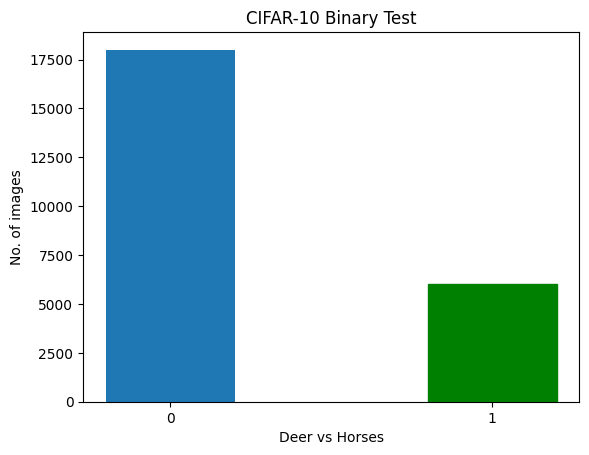

In [27]:
barlist = plt.bar([str(0),str(1)], data_source['Y'].value_counts(), width = 0.4)
barlist[1].set_color('g')

plt.xlabel("Deer vs Horses")
plt.ylabel("No. of images")
plt.title("CIFAR-10 Binary Test")
plt.show()

# Splitting for Source and Target Domains:


# Full Dataset:

For the Heart Disease prediction, we split the dataset between low education level (**now including high-school dropouts**) and the high education level. The high-education data (with diabetes as response variable/label) becomes the source data and the low-education data (with Heart Disease as response variable/label) is the target data.

In [28]:
data_source

,0,1,2,3,4,5,6,7,8,9,...,3064,3065,3066,3067,3068,3069,3070,3071,Y,test
0,0.349020,0.349020,0.349020,0.364706,0.364706,0.364706,0.329412,0.329412,0.329412,0.192157,...,0.729412,0.729412,0.725490,0.725490,0.725490,0.686275,0.686275,0.686275,0,0
1,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,...,0.823529,0.823529,0.811765,0.811765,0.811765,0.815686,0.815686,0.815686,0,0
2,0.145098,0.145098,0.117647,0.137255,0.133333,0.109804,0.203922,0.200000,0.188235,0.309804,...,0.133333,0.105882,0.094118,0.082353,0.043137,0.062745,0.062745,0.039216,0,0
3,0.149020,0.149020,0.149020,0.180392,0.180392,0.180392,0.180392,0.180392,0.180392,0.156863,...,0.517647,0.517647,0.525490,0.525490,0.525490,0.525490,0.525490,0.525490,0,0
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.933333,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.721569,0.596078,0.772549,0.709804,0.576471,0.780392,0.709804,0.572549,1,1
3996,0.062745,0.094118,0.050980,0.019608,0.058824,0.023529,0.031373,0.086275,0.043137,0.043137,...,0.415686,0.329412,0.498039,0.407843,0.321569,0.482353,0.400000,0.309804,1,1
3997,0.125490,0.129412,0.086275,0.172549,0.219608,0.117647,0.243137,0.274510,0.172549,0.380392,...,0.580392,0.494118,0.705882,0.580392,0.494118,0.698039,0.556863,0.478431,1,1
3998,0.329412,0.470588,0.384314,0.384314,0.490196,0.403922,0.388235,0.490196,0.411765,0.392157,...,0.580392,0.552941,0.498039,0.517647,0.498039,0.333333,0.352941,0.317647,1,1


In [29]:
data_target

,0,1,2,3,4,5,6,7,8,9,...,3064,3065,3066,3067,3068,3069,3070,3071,Y,test
0,0.490196,0.490196,0.454902,0.431373,0.396078,0.356863,0.400000,0.352941,0.325490,0.415686,...,0.458824,0.321569,0.560784,0.454902,0.329412,0.564706,0.454902,0.337255,0,0
1,0.431373,0.407843,0.380392,0.556863,0.529412,0.462745,0.592157,0.572549,0.470588,0.521569,...,0.188235,0.235294,0.184314,0.180392,0.235294,0.200000,0.188235,0.243137,0,0
2,0.988235,0.031373,0.164706,0.976471,0.058824,0.164706,0.980392,0.031373,0.152941,0.984314,...,0.305882,0.443137,0.980392,0.290196,0.427451,0.984314,0.227451,0.345098,0,0
3,0.513726,0.317647,0.125490,0.486275,0.298039,0.105882,0.454902,0.274510,0.078431,0.486275,...,0.407843,0.270588,0.611765,0.447059,0.286275,0.643137,0.462745,0.286275,0,0
4,0.027451,0.019608,0.031373,0.027451,0.019608,0.031373,0.019608,0.015686,0.023529,0.027451,...,0.325490,0.298039,0.262745,0.290196,0.317647,0.447059,0.470588,0.466667,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0.325490,0.321569,0.356863,0.321569,0.317647,0.349020,0.337255,0.333333,0.364706,0.482353,...,0.368627,0.419608,0.396078,0.388235,0.439216,0.372549,0.364706,0.415686,1,1
1496,0.062745,0.098039,0.098039,0.066667,0.094118,0.086275,0.054902,0.070588,0.050980,0.054902,...,0.709804,0.745098,0.619608,0.709804,0.741176,0.603922,0.698039,0.725490,1,1
1497,0.278431,0.329412,0.270588,0.078431,0.094118,0.070588,0.039216,0.035294,0.027451,0.066667,...,0.121569,0.160784,0.682353,0.109804,0.141176,0.560784,0.090196,0.105882,1,1
1498,0.556863,0.521569,0.513726,0.560784,0.525490,0.509804,0.541176,0.478431,0.439216,0.411765,...,0.698039,0.729412,0.717647,0.690196,0.717647,0.737255,0.713726,0.729412,1,1


## Transfer Learning Fine-Tuning:

In [30]:
def create_dnn_model(input_shape):
  model = models.Sequential([layers.Dense(64, activation='relu', input_dim=input_shape),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # For binary classification (yes/no diabetes)
    ])
  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

  model.summary()
  print(len(model.layers))

  return model

# def create_dnn_model(input_shape):
#   model = models.Sequential([layers.Dense(64, activation='relu', input_dim=input_shape),
#         layers.Dense(32, activation='relu'),
#         layers.Dense(1, activation='sigmoid')  # For binary classification (yes/no diabetes)
#     ])

#   model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

#   return model



def train_and_evaluate(model, X_train, X_test, y_train, y_test, domain):

    time_start = perf_counter()

    # Training and validation
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

    # Predict probabilities and calculate AUC
    y_pred_prob = model.predict(X_test).ravel()
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"AUC-ROC: {auc}")

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    # Convert probabilities to binary predictions for confusion matrix
    y_pred_class = (y_pred_prob >= 0.5).astype(int)

    # Compute and print classification report
    class_report = classification_report(y_test, y_pred_class)
    print("Classification Report:")
    print(class_report)

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred_class)
    conf_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)


    fpr = conf_matrix[0][1]/(conf_matrix[0][0]+conf_matrix[0][1])
    tnr = 1-fpr

    fnr = conf_matrix[1][0]/(conf_matrix[1][0] + conf_matrix[1][1])
    tpr = 1 - fnr
    print('FPR', fpr, 'TPR:', tpr, 'FNR:', fnr, 'TNR:', tnr)

    # Plot ROC curve and Confusion Matrix side by side
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # # ROC Curve
    # ax1.plot(fpr, tpr, color='blue', label=f'AUC-ROC = {auc:.2f}')
    # ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
    # ax1.set_xlabel('False Positive Rate')
    # ax1.set_ylabel('True Positive Rate')
    # ax1.set_title('Receiver Operating Characteristic (ROC) Curve')
    # ax1.legend(loc='lower right')
    # ax1.grid()

    # # Confusion Matrix
    # conf_disp.plot(ax=ax2, cmap='Blues')
    # ax2.set_title('Confusion Matrix')
    # plt.tight_layout()
    # plt.show()

    # Calculate precision and recall for different thresholds
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

    # Find the threshold where precision and recall are balanced
    f1_scores = 2 * (precision * recall) / (precision + recall)
    best_threshold = thresholds[f1_scores.argmax()]

    print(f"Best threshold based on F1-score: {best_threshold}")

    time_stop = perf_counter()

    print('Time elapsed (performance):', time_stop-time_start)

    model.save('model.h5')
    model.save_weights('model_wt.weights.h5')

    return model


In [31]:
def train_and_evaluate_nosave(model, X_train, X_test, y_train, y_test, domain):

    time_start = perf_counter()

    # Training and validation
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

    # Predict probabilities and calculate AUC
    y_pred_prob = model.predict(X_test).ravel()
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"AUC-ROC: {auc}")

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    # Convert probabilities to binary predictions for confusion matrix
    y_pred_class = (y_pred_prob >= 0.5).astype(int)

    # Compute and print classification report
    class_report = classification_report(y_test, y_pred_class)
    print("Classification Report:")
    print(class_report)

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred_class)
    conf_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)

    fpr = conf_matrix[0][1]/(conf_matrix[0][0]+conf_matrix[0][1])
    fnr = conf_matrix[1][0]/(conf_matrix[1][0] + conf_matrix[1][1])

    print(fpr)
    print(fnr)

    time_stop = perf_counter()

    print('Time elapsed (performance):', time_stop-time_start)

    return fpr, fnr


In [32]:
def fine_tuning(X_train, X_test, y_train, y_test, llim, ulim):
    new_model = create_dnn_model(X_S_train.shape[1])
    # new_model = tf.keras.models.load_model('model.h5')
    new_model.load_weights('model_wt.weights.h5')

    for layer in new_model.layers[llim:ulim]:
        layer.trainable = False
    for layer in new_model.layers[-1:]:
        layer.trainable = False

    for layer in new_model.layers:
        if layer.trainable == True:
          print("Trainable")
        else:
          print("Not Trainable")

    fpr, fnr = train_and_evaluate_nosave(new_model, X_train, X_test, y_train, y_test, "Target")
    return fpr, fnr

In [33]:
def Transductive_TL(model, X_test, y_test, domain):

    time_start = perf_counter()

    # Predict probabilities and calculate AUC
    y_pred_prob = model.predict(X_test).ravel()
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"AUC-ROC: {auc}")

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    # Convert probabilities to binary predictions for confusion matrix
    y_pred_class = (y_pred_prob >= 0.5).astype(int)

    # Compute and print classification report
    class_report = classification_report(y_test, y_pred_class)
    print("Classification Report:")
    print(class_report)

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred_class)
    conf_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)

    # # Plot ROC curve and Confusion Matrix side by side
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # # ROC Curve
    # ax1.plot(fpr, tpr, color='blue', label=f'AUC-ROC = {auc:.2f}')
    # ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
    # ax1.set_xlabel('False Positive Rate')
    # ax1.set_ylabel('True Positive Rate')
    # ax1.set_title('Receiver Operating Characteristic (ROC) Curve')
    # ax1.legend(loc='lower right')
    # ax1.grid()

    # Confusion Matrix
    # print('Confusion matrix:', conf_matrix)
    fpr = conf_matrix[0][1]/(conf_matrix[0][0]+conf_matrix[0][1])
    tnr = 1-fpr

    fnr = conf_matrix[1][0]/(conf_matrix[1][0] + conf_matrix[1][1])
    tpr = 1 - fnr
    print('FPR', fpr, 'TPR:', tpr, 'FNR:', fnr, 'TNR:', tnr)
    conf_disp.plot(ax=ax2, cmap='Blues')
    # ax2.set_title('Confusion Matrix')
    # plt.tight_layout()
    # plt.show()

    # Calculate precision and recall for different thresholds
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

    # Find the threshold where precision and recall are balanced
    f1_scores = 2 * (precision * recall) / (precision + recall)
    best_threshold = thresholds[f1_scores.argmax()]

    print(f"Best threshold based on F1-score: {best_threshold}")
    print('False Negative Rate:', fnr)

    time_stop = perf_counter()

    print('Time elapsed (performance):', time_stop-time_start)

# Over/undersampling functions:

## Undersampling functions:

In [34]:
import random

def SRS_undersampler(data, data_column):
    data_majority = data[data_column.isin([0])]
    data_minority = data[data_column.isin([1])]
    undersample_size = len(data_minority)
    oversample_size = len(data_majority)

    print(undersample_size)
    print(oversample_size)

    np.random.seed(333)
    data_maj_rus = data_majority.sample(n=undersample_size, replace=False)
    data_SRS_RUS = pd.concat([data_maj_rus, data_minority])
    X_SRS = data_SRS_RUS.iloc[:, :-1]
    y_SRS = data_SRS_RUS.iloc[:, -1]

    return X_SRS, y_SRS


def SRSwR_undersampler(data, data_column):
    data_majority = data[data_column.isin([0])]
    data_minority = data[data_column.isin([1])]
    undersample_size = len(data_minority)
    oversample_size = len(data_majority)

    print(undersample_size)
    print(oversample_size)

    np.random.seed(333)
    data_maj_rus = data_majority.sample(n=undersample_size, replace=True)
    data_SRS_RUS = pd.concat([data_maj_rus, data_minority])
    X_SRS = data_SRS_RUS.iloc[:, :-1]
    y_SRS = data_SRS_RUS.iloc[:, -1]

    return X_SRS, y_SRS


def systematic_undersampler(data, data_column):
    data_majority = data[data_column.isin([0])]
    data_minority = data[data_column.isin([1])]
    undersample_size = len(data_minority)
    oversample_size = len(data_majority)
    print(undersample_size)
    print(oversample_size)

    k = oversample_size/undersample_size
    print(k)
    np.random.seed(333)
    start = random.randint(1, int(k))
    print(start)
    Row = []
    for i in range(undersample_size):
      row = start+int(k*i)-1
      Row.append(row)
    print(Row)
    data_maj_rus = pd.DataFrame()
    data_maj_rus = data_majority.iloc[Row]
    data_maj_rus
    data_Sy_RUS = pd.concat([data_maj_rus, data_minority])

    X_Sy = data_Sy_RUS.iloc[:, :-1]
    y_Sy = data_Sy_RUS.iloc[:, -1]

    return X_Sy, y_Sy



def multi_systematic_undersampler(data, data_column, m):
    data_majority = data[data_column.isin([0])]
    data_minority = data[data_column.isin([1])]
    undersample_size = len(data_minority)
    oversample_size = len(data_majority)
    print(undersample_size)
    print(oversample_size)

    k = oversample_size/undersample_size
    print(k)
    np.random.seed(333)
    start = random.sample(range(1, int(k*m)), m)
    Row = []
    for j in range(len(start)):
      for i in range(int(undersample_size/m)):
        row = start[j]+int(k*i)-1
        Row.append(row)
    print(Row)
    data_maj_rus = pd.DataFrame()
    data_maj_rus = data_majority.iloc[Row]
    data_maj_rus
    data_Sy_RUS = pd.concat([data_maj_rus, data_minority])

    X_Sy = data_Sy_RUS.iloc[:, :-1]
    y_Sy = data_Sy_RUS.iloc[:, -1]

    return X_Sy, y_Sy

## Oversampling functions:

In [35]:
def SRSwR_oversampler(data, data_column):
    data_majority = data[data_column.isin([0])]
    data_minority = data[data_column.isin([1])]
    undersample_size = len(data_minority)
    oversample_size = len(data_majority)

    print(undersample_size)
    print(oversample_size)

    np.random.seed(333)
    data_min_ros = data_minority.sample(n=oversample_size - undersample_size, replace=True)
    data_SRS_ROS = pd.concat([data_majority, data_minority, data_min_ros])
    X_SRS = data_SRS_ROS.iloc[:, :-1]
    y_SRS = data_SRS_ROS.iloc[:, -1]

    return X_SRS, y_SRS

# data_S_min_ros = data_S_minority.sample(n=oversample_size - undersample_size, replace=True)


def systematic_resampler(data, data_column, k):
    data_majority = data[data_column.isin([0])]
    data_minority = data[data_column.isin([1])]
    undersample_size = len(data_minority)
    oversample_size = len(data_majority)

    print(undersample_size)
    print(oversample_size)

    Nsamples = k*(oversample_size-undersample_size)/undersample_size
    print('Nsamples=', Nsamples)

    np.random.seed(333)
    start = np.random.choice(int(k), int(Nsamples), replace=True)
    Row = []
    for j in range(len(start)):
      for i in range(int(undersample_size/k)):
        row = start[j]+int(k*i)-1
        Row.append(row)
    data_min_ros = pd.DataFrame()
    data_min_ros = data_minority.iloc[Row]

    data_Sy_ROS = pd.concat([data_majority, data_minority, data_min_ros])
    X_Sy = data_Sy_ROS.iloc[:, :-1]
    y_Sy = data_Sy_ROS.iloc[:, -1]

    return X_Sy, y_Sy

# k = 48

# Nsamples = k*(oversample_size-undersample_size)/undersample_size
# # print(Nsamples)

# np.random.seed(123)
# start = np.random.choice(int(k), int(Nsamples), replace=True)
# # print(start)


# Row = []

# for j in range(len(start)):
#   for i in range(int(undersample_size/k)):
#     row = start[j]+int(k*i)-1
#     Row.append(row)

In [36]:
data_source_train = data_source[data_source['test']==0].iloc[:,:-1]
data_source_test = data_source[data_source['test']==1].iloc[:,:-1]

data_target_train = data_target[data_target['test']==0].iloc[:,:-1]
data_target_test = data_target[data_target['test']==1].iloc[:,:-1]

data_target_test


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
0,0.619608,0.439216,0.192157,0.623529,0.435294,0.184314,0.647059,0.454902,0.200000,0.650980,...,0.094118,0.301961,0.486275,0.133333,0.329412,0.505882,0.082353,0.262745,0.431373,0
1,0.090196,0.074510,0.090196,0.074510,0.082353,0.109804,0.082353,0.062745,0.074510,0.254902,...,0.584314,0.517647,0.462745,0.607843,0.537255,0.482353,0.588235,0.517647,0.462745,0
2,0.086275,0.105882,0.074510,0.117647,0.141176,0.101961,0.117647,0.141176,0.090196,0.117647,...,0.262745,0.282353,0.309804,0.223529,0.239216,0.278431,0.227451,0.243137,0.282353,0
3,1.000000,1.000000,0.984314,0.976471,0.984314,0.964706,0.898039,0.882353,0.850980,0.627451,...,0.023529,0.007843,0.000000,0.031373,0.007843,0.000000,0.050980,0.023529,0.011765,0
4,0.039216,0.039216,0.039216,0.039216,0.039216,0.039216,0.039216,0.039216,0.039216,0.039216,...,0.439216,0.341176,0.262745,0.458824,0.364706,0.282353,0.498039,0.411765,0.321569,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0.325490,0.321569,0.356863,0.321569,0.317647,0.349020,0.337255,0.333333,0.364706,0.482353,...,0.376471,0.368627,0.419608,0.396078,0.388235,0.439216,0.372549,0.364706,0.415686,1
1496,0.062745,0.098039,0.098039,0.066667,0.094118,0.086275,0.054902,0.070588,0.050980,0.054902,...,0.627451,0.709804,0.745098,0.619608,0.709804,0.741176,0.603922,0.698039,0.725490,1
1497,0.278431,0.329412,0.270588,0.078431,0.094118,0.070588,0.039216,0.035294,0.027451,0.066667,...,0.733333,0.121569,0.160784,0.682353,0.109804,0.141176,0.560784,0.090196,0.105882,1
1498,0.556863,0.521569,0.513726,0.560784,0.525490,0.509804,0.541176,0.478431,0.439216,0.411765,...,0.725490,0.698039,0.729412,0.717647,0.690196,0.717647,0.737255,0.713726,0.729412,1


In [37]:
X_S_train = data_source_train.iloc[:,:-1]
y_S_train = data_source_train.iloc[:,-1]

X_S_test = data_source_test.iloc[:,:-1]
y_S_test = data_source_test.iloc[:,-1]

X_T_train = data_target_train.iloc[:,:-1]
y_T_train = data_target_train.iloc[:,-1]

X_T_test = data_target_test.iloc[:,:-1]
y_T_test = data_target_test.iloc[:,-1]

X_T_test


,0,1,2,3,4,5,6,7,8,9,...,3062,3063,3064,3065,3066,3067,3068,3069,3070,3071
0,0.619608,0.439216,0.192157,0.623529,0.435294,0.184314,0.647059,0.454902,0.200000,0.650980,...,0.568627,0.094118,0.301961,0.486275,0.133333,0.329412,0.505882,0.082353,0.262745,0.431373
1,0.090196,0.074510,0.090196,0.074510,0.082353,0.109804,0.082353,0.062745,0.074510,0.254902,...,0.396078,0.584314,0.517647,0.462745,0.607843,0.537255,0.482353,0.588235,0.517647,0.462745
2,0.086275,0.105882,0.074510,0.117647,0.141176,0.101961,0.117647,0.141176,0.090196,0.117647,...,0.341176,0.262745,0.282353,0.309804,0.223529,0.239216,0.278431,0.227451,0.243137,0.282353
3,1.000000,1.000000,0.984314,0.976471,0.984314,0.964706,0.898039,0.882353,0.850980,0.627451,...,0.003922,0.023529,0.007843,0.000000,0.031373,0.007843,0.000000,0.050980,0.023529,0.011765
4,0.039216,0.039216,0.039216,0.039216,0.039216,0.039216,0.039216,0.039216,0.039216,0.039216,...,0.290196,0.439216,0.341176,0.262745,0.458824,0.364706,0.282353,0.498039,0.411765,0.321569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0.325490,0.321569,0.356863,0.321569,0.317647,0.349020,0.337255,0.333333,0.364706,0.482353,...,0.396078,0.376471,0.368627,0.419608,0.396078,0.388235,0.439216,0.372549,0.364706,0.415686
1496,0.062745,0.098039,0.098039,0.066667,0.094118,0.086275,0.054902,0.070588,0.050980,0.054902,...,0.752941,0.627451,0.709804,0.745098,0.619608,0.709804,0.741176,0.603922,0.698039,0.725490
1497,0.278431,0.329412,0.270588,0.078431,0.094118,0.070588,0.039216,0.035294,0.027451,0.066667,...,0.156863,0.733333,0.121569,0.160784,0.682353,0.109804,0.141176,0.560784,0.090196,0.105882
1498,0.556863,0.521569,0.513726,0.560784,0.525490,0.509804,0.541176,0.478431,0.439216,0.411765,...,0.749020,0.725490,0.698039,0.729412,0.717647,0.690196,0.717647,0.737255,0.713726,0.729412


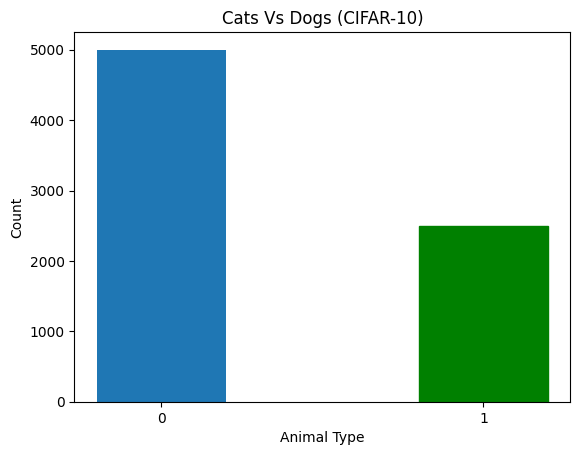

In [38]:
barlist = plt.bar([str(0),str(1)], y_T_train.value_counts(), width = 0.4)
barlist[1].set_color('g')

plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.title("Cats Vs Dogs (CIFAR-10)")
plt.show()

In [39]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (20000, 3072)
y_S_train: (20000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [40]:
print('X_T_train:',np.shape(X_T_train))
print('y_T_train:',np.shape(y_T_train))
print('X_T_test:',np.shape(X_T_test))
print('y_T_test:',np.shape(y_T_test))

X_T_train: (7500, 3072)
y_T_train: (7500,)
X_T_test: (1500, 3072)
y_T_test: (1500,)


# Original (Imbalanced) dataset:

## Standard Machine Learning:

In [ ]:
model_source = create_dnn_model(X_T_train.shape[1])
train_and_evaluate(model_source, X_T_train, X_T_test, y_T_train, y_T_test, "Target")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - AUC: 0.0000e+00 - loss: 0.0463 - val_AUC: 0.0000e+00 - val_loss: 31.3902
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.0000e+00 - loss: 1.3937e-06 - val_AUC: 0.0000e+00 - val_loss: 36.7226
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.0000e+00 - loss: 8.0177e-07 - val_AUC: 0.0000e+00 - val_loss: 42.9909
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.0000e+00 - loss: 3.6475e-07 - val_AUC: 0.0000e+00 - val_loss: 48.8076
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.0000e+00 - loss: 5.5903e-08 - val_AUC: 0.0000e+00 - val_loss: 52.3478
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.0000e+00 - loss: 4.2438e-08 - val_AUC: 0.0000e+00 - val_loss: 55.0377
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.0000e+00 - loss: 1.1613e-07 - val_AUC: 0.0000e+00 - val_loss: 57.0429
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.0000e+00 - loss: 1.4514

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipython-input-1640304047.py:86: RuntimeWarni

AUC-ROC: 0.47018799999999994
Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1000
           1       0.00      0.00      0.00       250

    accuracy                           0.80      1250
   macro avg       0.40      0.50      0.44      1250
weighted avg       0.64      0.80      0.71      1250

FPR 0.0 TPR: 0.0 FNR: 1.0 TNR: 1.0
Best threshold based on F1-score: 1.015511372909339e-11
Time elapsed (performance): 13.288368941000044


<Sequential name=sequential, built=True>

## With Transfer Learning:

In [ ]:
times_train = 1
times_fine_tune = 2


FPR = []
FNR = []

for i in range(times_train):
  model_source = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train, X_T_test, y_T_train, y_T_test, 0, 4)
    # print(output)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - AUC: 0.4868 - loss: 5.0259 - val_AUC: 0.0000e+00 - val_loss: 1.7172
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.4733 - loss: 0.4844 - val_AUC: 0.0000e+00 - val_loss: 2.5280
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.4850 - loss: 0.5228 - val_AUC: 0.0000e+00 - val_loss: 2.4652
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.4807 - loss: 0.5026 - val_AUC: 0.0000e+00 - val_loss: 2.5147
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.4840 - loss: 0.4902 - val_AUC: 0.0000e+00 - val_loss: 1.8319
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.4734 - loss: 0.4904 - val_AUC: 0.0000e+00 - val_loss: 2.4098
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - AUC: 0.4962 - loss: 0.4702 - val_AUC: 0.0000e+00 - val_loss: 1.6989
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.4956 - loss: 0.4899 - val_AUC: 0.0000e+00 - val_loss: 2.2731
Epoch 9/10
188/188 ━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(ParamFit)
ParamFit.to_csv('Fine_Tuning_Imbalanced.csv')

   FPR  FNR
0  0.0  1.0
1  0.0  1.0


In [ ]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  1.0
StDev:  0.0


# Random Undersampling (RUS) to balance Dataset:

## SRS Sample without Replacement:

In [ ]:
X_S_train, y_S_train = SRS_undersampler(data_source_train, data_source_train['Y'])
# X_S_test, y_S_test = SRS_undersampler(data_source_test, data_source_test['Y'])
X_T_train_SRS, y_T_train_SRS = SRS_undersampler(data_source_train, data_source_train['Y'])
# print(y_S_SRS)

print(y_T_train_SRS)

5000
15000
5000
15000
5622     0
7602     0
3858     0
7739     0
6987     0
        ..
19995    1
19996    1
19997    1
19998    1
19999    1
Name: Y, Length: 10000, dtype: int64


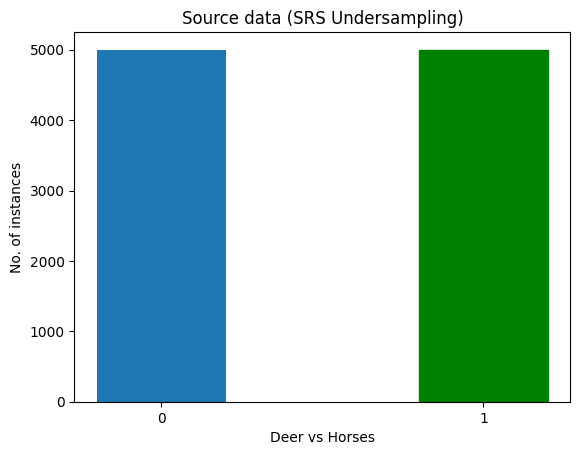

In [ ]:
barlist = plt.bar([str(0),str(1)], y_S_train.value_counts(), width = 0.4)
barlist[1].set_color('g')

plt.xlabel("Deer vs Horses")
plt.ylabel("No. of instances")
plt.title("Source data (SRS Undersampling)")
plt.show()

In [ ]:
y_T_train_SRS.value_counts()

,count
Y,
0,5000
1,5000


In [ ]:
y_S_test.value_counts()

,count
Y,
0,3000
1,1000


In [ ]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (10000, 3072)
y_S_train: (10000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [ ]:
times_train = 10
times_fine_tune = 10

FPR = []
FNR = []

for i in range(times_train):
  model_source_SRS = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source_SRS, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train_SRS, X_T_test, y_T_train_SRS, y_T_test, 0, 4)
    # print(output)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']


# fine_tuning(X_T_train_SRS, X_T_test, y_T_train_SRS, y_T_test, 0, 4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - AUC: 0.9257 - loss: 0.3267 - val_AUC: 0.0000e+00 - val_loss: 0.4786
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9275 - loss: 0.3109 - val_AUC: 0.0000e+00 - val_loss: 0.4965
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.9309 - loss: 0.3043 - val_AUC: 0.0000e+00 - val_loss: 0.5846
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9352 - loss: 0.3008 - val_AUC: 0.0000e+00 - val_loss: 0.5075
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9343 - loss: 0.3016 - val_AUC: 0.0000e+00 - val_loss: 0.5957
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9347 - loss: 0.2979 - val_AUC: 0.0000e+00 - val_loss: 0.4681
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9355 - loss: 0.2992 - val_AUC: 0.0000e+00 - val_loss: 0.5826
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9310 - loss: 0.3048 - val_AUC: 0.0000e+00 - val_loss: 0.4739
Epoch 9/10
250/250 ━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('SRS_Fine_Tuning.csv')

      FPR    FNR
0   0.299  0.684
1   0.291  0.684
2   0.304  0.680
3   0.294  0.676
4   0.306  0.682
..    ...    ...
95  0.339  0.626
96  0.280  0.702
97  0.313  0.658
98  0.273  0.714
99  0.305  0.658

[100 rows x 2 columns]


In [ ]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  0.65972
StDev:  0.023769975119291086


## Simple Random Sampling with Replacement:

In [ ]:
X_S_train, y_S_train = SRSwR_undersampler(data_source_train, data_source_train['Y'])
# X_S_test, y_S_test = SRSwR_undersampler(data_source_test, data_source_test['Y'])
X_T_train_SRSwR, y_T_train_SRSwR = SRSwR_undersampler(data_source_train, data_source_train['Y'])
# print(y_S_SRS)

print(y_T_train_SRSwR)

5000
15000
5000
15000
8172     0
14092    0
973      0
9635     0
6067     0
        ..
19995    1
19996    1
19997    1
19998    1
19999    1
Name: Y, Length: 10000, dtype: int64


In [ ]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (10000, 3072)
y_S_train: (10000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [ ]:
times_train = 10
times_fine_tune = 10

FPR = []
FNR = []

for i in range(times_train):
  model_source_SRSwR = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source_SRSwR, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train_SRSwR, X_T_test, y_T_train_SRSwR, y_T_test, 0, 4)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']

# fine_tuning(X_T_train_SRSwR, X_T_test, y_T_train_SRSwR, y_T_test, 0, 4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - AUC: 0.9277 - loss: 0.3110 - val_AUC: 0.0000e+00 - val_loss: 0.5861
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9287 - loss: 0.3129 - val_AUC: 0.0000e+00 - val_loss: 0.5518
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.9299 - loss: 0.3098 - val_AUC: 0.0000e+00 - val_loss: 0.5313
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.9300 - loss: 0.3095 - val_AUC: 0.0000e+00 - val_loss: 0.4714
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9275 - loss: 0.3137 - val_AUC: 0.0000e+00 - val_loss: 0.5834
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9303 - loss: 0.3040 - val_AUC: 0.0000e+00 - val_loss: 0.5167
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9309 - loss: 0.3045 - val_AUC: 0.0000e+00 - val_loss: 0.5383
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9300 - loss: 0.3040 - val_AUC: 0.0000e+00 - val_loss: 0.5411
Epoch 9/10
250/250 ━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('SRSwR_Fine_Tuning.csv')

      FPR    FNR
0   0.299  0.678
1   0.296  0.680
2   0.340  0.648
3   0.306  0.666
4   0.347  0.658
..    ...    ...
95  0.338  0.634
96  0.290  0.686
97  0.296  0.684
98  0.289  0.688
99  0.289  0.686

[100 rows x 2 columns]


In [ ]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  0.6695200000000001
StDev:  0.017723168652097925


## Systematic Sampling:

First, we select a single systematic sample from the majority class, in which $k = \frac{N_0}{N_1}$, where $N_0$ is the majority class size in the source domain and $N_1$ is the minority class in the source domain.

In [ ]:
X_S_train, y_S_train = systematic_undersampler(data_source_train, data_source_train['Y'])
# X_S_test, y_S_test = systematic_undersampler(data_source_test, data_source_test['Y'])
X_T_train_Sy, y_T_train_Sy = systematic_undersampler(data_source_train, data_source_train['Y'])
# print(y_S_SRS)

print(y_T_train_Sy)

5000
15000
3.0
2
[1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46, 49, 52, 55, 58, 61, 64, 67, 70, 73, 76, 79, 82, 85, 88, 91, 94, 97, 100, 103, 106, 109, 112, 115, 118, 121, 124, 127, 130, 133, 136, 139, 142, 145, 148, 151, 154, 157, 160, 163, 166, 169, 172, 175, 178, 181, 184, 187, 190, 193, 196, 199, 202, 205, 208, 211, 214, 217, 220, 223, 226, 229, 232, 235, 238, 241, 244, 247, 250, 253, 256, 259, 262, 265, 268, 271, 274, 277, 280, 283, 286, 289, 292, 295, 298, 301, 304, 307, 310, 313, 316, 319, 322, 325, 328, 331, 334, 337, 340, 343, 346, 349, 352, 355, 358, 361, 364, 367, 370, 373, 376, 379, 382, 385, 388, 391, 394, 397, 400, 403, 406, 409, 412, 415, 418, 421, 424, 427, 430, 433, 436, 439, 442, 445, 448, 451, 454, 457, 460, 463, 466, 469, 472, 475, 478, 481, 484, 487, 490, 493, 496, 499, 502, 505, 508, 511, 514, 517, 520, 523, 526, 529, 532, 535, 538, 541, 544, 547, 550, 553, 556, 559, 562, 565, 568, 571, 574, 577, 580, 583, 586, 589, 592, 595, 598, 601, 604, 607, 610

In [ ]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (10000, 3072)
y_S_train: (10000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [ ]:
times_train = 10
times_fine_tune = 10


FPR = []
FNR = []

for i in range(times_train):
  model_source_Sy = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source_Sy, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train_Sy, X_T_test, y_T_train_Sy, y_T_test, 0, 4)
    # print(output)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']


# fine_tuning(X_T_train_Sy, X_T_test, y_T_train_Sy, y_T_test, 0, 4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - AUC: 0.9200 - loss: 0.3337 - val_AUC: 0.0000e+00 - val_loss: 0.5456
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.9169 - loss: 0.3391 - val_AUC: 0.0000e+00 - val_loss: 0.5555
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9185 - loss: 0.3322 - val_AUC: 0.0000e+00 - val_loss: 0.5463
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.9275 - loss: 0.3148 - val_AUC: 0.0000e+00 - val_loss: 0.5278
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9204 - loss: 0.3316 - val_AUC: 0.0000e+00 - val_loss: 0.5460
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9259 - loss: 0.3182 - val_AUC: 0.0000e+00 - val_loss: 0.5980
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9239 - loss: 0.3226 - val_AUC: 0.0000e+00 - val_loss: 0.5148
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9278 - loss: 0.3180 - val_AUC: 0.0000e+00 - val_loss: 0.5401
Epoch 9/10
250/250 ━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_Sy_Fine_Tuning.csv')

      FPR    FNR
0   0.311  0.660
1   0.303  0.658
2   0.292  0.660
3   0.335  0.644
4   0.295  0.678
..    ...    ...
95  0.305  0.648
96  0.309  0.652
97  0.301  0.662
98  0.311  0.646
99  0.303  0.670

[100 rows x 2 columns]


In [ ]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  0.6606800000000002
StDev:  0.014869723832966333


## Systematic Sampling (multiple samples):

Now, we investigate the possibility of conducting $m$ systematic samples, each with a sampling interval of $k=m*\frac{N_0}{N_1}$, and obtaining the undersampled majority class data using all $m$ systematic samples combined. This may more closely approximate SRS sampling.


In [ ]:
X_S_train, y_S_train = multi_systematic_undersampler(data_source_train, data_source_train['Y'],2)
# X_S_test, y_S_test = multi_systematic_undersampler(data_source_test, data_source_test['Y'],10)
X_T_train_Sy, y_T_train_Sy = multi_systematic_undersampler(data_source_train, data_source_train['Y'],2)
# print(y_S_SRS)

print(y_T_train_Sy)

5000
15000
3.0
[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195, 198, 201, 204, 207, 210, 213, 216, 219, 222, 225, 228, 231, 234, 237, 240, 243, 246, 249, 252, 255, 258, 261, 264, 267, 270, 273, 276, 279, 282, 285, 288, 291, 294, 297, 300, 303, 306, 309, 312, 315, 318, 321, 324, 327, 330, 333, 336, 339, 342, 345, 348, 351, 354, 357, 360, 363, 366, 369, 372, 375, 378, 381, 384, 387, 390, 393, 396, 399, 402, 405, 408, 411, 414, 417, 420, 423, 426, 429, 432, 435, 438, 441, 444, 447, 450, 453, 456, 459, 462, 465, 468, 471, 474, 477, 480, 483, 486, 489, 492, 495, 498, 501, 504, 507, 510, 513, 516, 519, 522, 525, 528, 531, 534, 537, 540, 543, 546, 549, 552, 555, 558, 561, 564, 567, 570, 573, 576, 579, 582, 585, 588, 591, 594, 597, 600, 603, 606, 609, 61

In [ ]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (10000, 3072)
y_S_train: (10000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [ ]:
y_S_test.value_counts()

,count
Y,
0,3000
1,1000


In [ ]:
times_train = 10
times_fine_tune = 10

FPR = []
FNR = []

for i in range(times_train):
  model_source_Sy = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source_Sy, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train_Sy, X_T_test, y_T_train_Sy, y_T_test, 0, 4)
    # print(output)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']

# fine_tuning(X_T_train_Sy, X_T_test, y_T_train_Sy, y_T_test, 0, 4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - AUC: 0.9247 - loss: 0.3276 - val_AUC: 0.0000e+00 - val_loss: 0.5518
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9280 - loss: 0.3193 - val_AUC: 0.0000e+00 - val_loss: 0.5586
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9248 - loss: 0.3238 - val_AUC: 0.0000e+00 - val_loss: 0.5756
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.9228 - loss: 0.3293 - val_AUC: 0.0000e+00 - val_loss: 0.6042
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9233 - loss: 0.3297 - val_AUC: 0.0000e+00 - val_loss: 0.5084
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9220 - loss: 0.3302 - val_AUC: 0.0000e+00 - val_loss: 0.5686
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9250 - loss: 0.3243 - val_AUC: 0.0000e+00 - val_loss: 0.6173
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9234 - loss: 0.3256 - val_AUC: 0.0000e+00 - val_loss: 0.5887
Epoch 9/10
250/250 ━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_Sy_multi_Fine_Tuning.csv')

      FPR    FNR
0   0.289  0.662
1   0.277  0.678
2   0.308  0.640
3   0.294  0.660
4   0.307  0.638
..    ...    ...
95  0.307  0.674
96  0.313  0.666
97  0.330  0.634
98  0.314  0.664
99  0.293  0.686

[100 rows x 2 columns]


In [ ]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  0.6674000000000001
StDev:  0.01966281420921894


# Random Oversampling (ROS):

## Simple Random Sampling with Replacement:

In this case, we investigate the effectiveness of Random Oversampling methods, beginning with Simple Random Sampling (SRS) with replacement. For this, we perform random resampling from the minority class of size $N_1$ to generate an additional sample of size $N_0-N_1$, such that the oversampled minority class will have the same size as the majority class.

In [57]:
X_S_train, y_S_train = SRSwR_oversampler(data_source_train, data_source_train['Y'])
# X_S_test, y_S_test = SRSwR_oversampler(data_source_test, data_source_test['Y'])
X_T_train_SRS, y_T_train_SRS = SRSwR_oversampler(data_source_train, data_source_train['Y'])
# print(y_S_SRS)

print(y_T_train_SRS)

5000
15000
5000
15000
0        0
1        0
2        0
3        0
4        0
        ..
19643    1
17930    1
19534    1
15722    1
16472    1
Name: Y, Length: 30000, dtype: int64


In [58]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (30000, 3072)
y_S_train: (30000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [62]:
times_train = 5
times_fine_tune = 10

FPR = []
FNR = []

for i in range(times_train):
  model_source_SRS_ROS = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source_SRS_ROS, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train_SRS, X_T_test, y_T_train_SRS, y_T_test, 0, 4)
    # print(output)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']

# fine_tuning(X_T_train_SRS, X_T_test, y_T_train_SRS, y_T_test, 0, 4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_220"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1540 (Dense)              │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1541 (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1542 (Dense)              │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1543 (Dense)              │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1544 (Dense)              │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1545 (Dense)              │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1546 (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - AUC: 0.9497 - loss: 0.2647 - val_AUC: 0.0000e+00 - val_loss: 0.3691
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - AUC: 0.9515 - loss: 0.2601 - val_AUC: 0.0000e+00 - val_loss: 0.4309
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.9527 - loss: 0.2560 - val_AUC: 0.0000e+00 - val_loss: 0.4214
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - AUC: 0.9542 - loss: 0.2516 - val_AUC: 0.0000e+00 - val_loss: 0.3753
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.9536 - loss: 0.2542 - val_AUC: 0.0000e+00 - val_loss: 0.3917
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.9523 - loss: 0.2565 - val_AUC: 0.0000e+00 - val_loss: 0.4062
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.9553 - loss: 0.2487 - val_AUC: 0.0000e+00 - val_loss: 0.4075
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.9519 - loss: 0.2586 - val_AUC: 0.0000e+00 - val_loss: 0.3890
Epoch 9/10
750/750 ━━━━━

In [63]:
print(ParamFit)
ParamFit.to_csv('CIFAR_SRS_ROS_Fine_Tuning.csv')

      FPR    FNR
0   0.363  0.616
1   0.375  0.600
2   0.367  0.616
3   0.363  0.606
4   0.358  0.614
5   0.352  0.616
6   0.352  0.616
7   0.375  0.594
8   0.356  0.618
9   0.367  0.608
10  0.303  0.666
11  0.339  0.614
12  0.315  0.636
13  0.360  0.582
14  0.345  0.604
15  0.352  0.594
16  0.318  0.626
17  0.352  0.598
18  0.344  0.600
19  0.339  0.604
20  0.308  0.648
21  0.299  0.670
22  0.356  0.592
23  0.339  0.588
24  0.307  0.666
25  0.350  0.604
26  0.318  0.638
27  0.340  0.594
28  0.321  0.626
29  0.328  0.622
30  0.335  0.628
31  0.344  0.606
32  0.358  0.598
33  0.387  0.564
34  0.333  0.636
35  0.361  0.576
36  0.362  0.592
37  0.325  0.634
38  0.382  0.576
39  0.385  0.572
40  0.311  0.638
41  0.320  0.628
42  0.336  0.608
43  0.336  0.606
44  0.349  0.602
45  0.310  0.640
46  0.321  0.624
47  0.338  0.614
48  0.346  0.600
49  0.328  0.612


In [64]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  0.6126
StDev:  0.023258090538782524


## Systematic Resampling:

In this case, we examine the possibility of performing Random Oversampling on the minority class using systematic sampling. For this purpose, taking a sampling interval of $k$, we would compile a total of $k*\frac{N_0-N_1}{N_1}$ systematic samples from the minority class in order to balance the dataset. We sample the starting point from 1 to $k$ *with replacement*, since a highly imbalanced dataset will require sampling with replacement in order to achieve a balanced dataset.

In particular, we take $k=10$ for the source data sampling, and take $k=20$ for the target training data resampling.

In [52]:
X_S_train, y_S_train = systematic_resampler(data_source_train, data_source_train['Y'], 10)
# X_S_test, y_S_test = systematic_resampler(data_source_test, data_source_test['Y'], 10)
X_T_train_Sy, y_T_train_Sy = systematic_resampler(data_source_train, data_source_train['Y'], 10)
# print(y_S_SRS)

print(y_T_train_Sy)

5000
15000
Nsamples= 20.0
5000
15000
Nsamples= 20.0
0        0
1        0
2        0
3        0
4        0
        ..
19958    1
19968    1
19978    1
19988    1
19998    1
Name: Y, Length: 30000, dtype: int64


In [53]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (30000, 3072)
y_S_train: (30000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [54]:
times_train = 5
times_fine_tune = 10

FPR = []
FNR = []

for i in range(times_train):
  model_source_Sy_ROS = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source_Sy_ROS, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train_Sy, X_T_test, y_T_train_Sy, y_T_test, 0, 4)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']

# fine_tuning(X_T_train_Sy, X_T_test, y_T_train_Sy, y_T_test, 0, 4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_110"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_770 (Dense)               │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_771 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_772 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_773 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_774 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_775 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_776 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - AUC: 0.9566 - loss: 0.2463 - val_AUC: 0.0000e+00 - val_loss: 0.3598
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.9604 - loss: 0.2343 - val_AUC: 0.0000e+00 - val_loss: 0.3481
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.9612 - loss: 0.2343 - val_AUC: 0.0000e+00 - val_loss: 0.3280
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.9600 - loss: 0.2375 - val_AUC: 0.0000e+00 - val_loss: 0.3818
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.9603 - loss: 0.2373 - val_AUC: 0.0000e+00 - val_loss: 0.3356
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.9608 - loss: 0.2350 - val_AUC: 0.0000e+00 - val_loss: 0.3448
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.9594 - loss: 0.2405 - val_AUC: 0.0000e+00 - val_loss: 0.3616
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.9602 - loss: 0.2374 - val_AUC: 0.0000e+00 - val_loss: 0.3665
Epoch 9/10
750/750 ━━━━━

In [55]:
print(ParamFit)
ParamFit.to_csv('CIFAR_Sy_ROS_Fine_Tuning.csv')

      FPR    FNR
0   0.326  0.630
1   0.300  0.640
2   0.304  0.642
3   0.317  0.642
4   0.294  0.642
5   0.308  0.636
6   0.325  0.612
7   0.316  0.632
8   0.310  0.642
9   0.334  0.614
10  0.328  0.620
11  0.331  0.628
12  0.360  0.592
13  0.310  0.624
14  0.345  0.604
15  0.314  0.630
16  0.339  0.616
17  0.330  0.616
18  0.354  0.604
19  0.319  0.630
20  0.377  0.572
21  0.354  0.588
22  0.373  0.572
23  0.387  0.576
24  0.383  0.566
25  0.375  0.574
26  0.392  0.562
27  0.385  0.564
28  0.362  0.586
29  0.357  0.590
30  0.299  0.646
31  0.282  0.664
32  0.298  0.640
33  0.286  0.662
34  0.321  0.624
35  0.298  0.650
36  0.298  0.644
37  0.333  0.614
38  0.307  0.640
39  0.285  0.660
40  0.278  0.648
41  0.287  0.644
42  0.269  0.662
43  0.285  0.640
44  0.288  0.648
45  0.281  0.654
46  0.290  0.638
47  0.292  0.640
48  0.283  0.644
49  0.296  0.628


In [56]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  0.6227199999999999
StDev:  0.028735983273482726
